<a href="https://colab.research.google.com/github/monasolgi/Computer_vision/blob/main/tutorial6_Saliency_map_CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task 1– Saliency Map in Python**



image shape: torch.Size([3, 224, 224])
batch shape: torch.Size([1, 3, 224, 224])
score: 0.4095992147922516
class id: 20
prediction shape: torch.Size([1000])


absolute gradient shape: (1, 3, 224, 224)
saliency shape: (1, 224, 224)
preprocessed image shape: (3, 224, 224)
preprocessed image shape for plotting: (224, 224, 3)


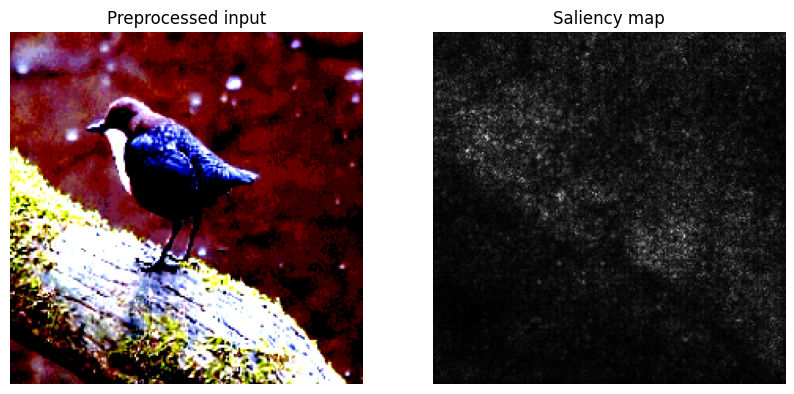

In [ ]:
# Install torchinfo for model summary
!pip install torchinfo

import torch
import torchinfo
import numpy as np
import matplotlib.pyplot as plt

from torchvision.io import decode_image
from torchvision.models import resnet50, ResNet50_Weights


# Load a model pretrained on ImageNet
# =========================================

weights = ResNet50_Weights.IMAGENET1K_V2
model = resnet50(weights=weights)
model.eval()

# torchinfo.summary(model, input_size=(1, 3, 224, 224))


# Load and preprocess image
# =========================================

img = decode_image("/content/ouzel.png")  # returns a PyTorch tensor (C,H,W)
preprocess = weights.transforms()         # preprocess image for resnet

print("image shape:", img.shape)  # [3, 224, 224]

batch = preprocess(img).unsqueeze(0)
print("batch shape:", batch.shape)  # [1, 3, 224, 224] the input expected by resnet


# Predict class
# =========================================

prediction = model(batch).squeeze(0).softmax(0)  # squeeze removes dimension of size 1

class_id = prediction.argmax().item()  # class_id=20
score = prediction[class_id].item()    # score=0.4095992147922516

print("score:", score)
print("class id:", class_id)
print("prediction shape:", prediction.shape)  # [1000]


# Compute gradient of the output of a model <model> with respect to its input <inp>
# If the output of the model is a vector, <output_index> chooses which element of output to use
# =========================================

def gradient_input(model, inp, output_index):
    inp = inp.clone().detach().requires_grad_(True)

    output = model(inp).squeeze(0)  # forward inference # output of classifier (B,num_classes)
    output = output.softmax(0)

    my_output = output[output_index]  # extract only the prediction of ouzel class

    model.zero_grad()
    my_output.backward()

    gradient = inp.grad
    return gradient


grad = gradient_input(model, batch, class_id)

# print(grad)
# print("output shape:", grad.shape)  # [1, 3, 224, 224] # grad w.r.t each pixel of our input-  same shape as input


# Construct saliency map
# =========================================

abs_grad = np.abs(grad.detach().numpy()) #Convert tensor → numpy
print("absolute gradient shape:", abs_grad.shape)  # (1, 3, 224, 224)

saliency = np.max(abs_grad, axis=1) # maximize over channels
print("saliency shape:", saliency.shape)  # (1, 224, 224)


# Prepare preprocessed image for plotting
# =========================================

img_prep = batch[0].detach().numpy()
print("preprocessed image shape:", img_prep.shape)  # (3, 224, 224)

img_prep = np.transpose(img_prep, (1, 2, 0))
print("preprocessed image shape for plotting:", img_prep.shape)  # (224, 224, 3) for plotting

# normalize the image for plotting (x - min)/(max - min), not (x - mean)/std
# img_prep = (img_prep - img_prep.min()) / (img_prep.max() - img_prep.min())


# Plot and save comparison
# =========================================

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(img_prep)
ax[0].set_title("Preprocessed input")
ax[0].axis("off")

ax[1].imshow(saliency[0], cmap="gray")  # show the first image of batch
ax[1].set_title("Saliency map")
ax[1].axis("off")

plt.savefig("comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# **Task 2– Gradient of Node at Intermediate Layer With Respect to input**

my_output shape: torch.Size([])
gradient shape: torch.Size([1, 1, 128, 128])
absolute gradient shape: (1, 1, 128, 128)
saliency shape: (128, 128)


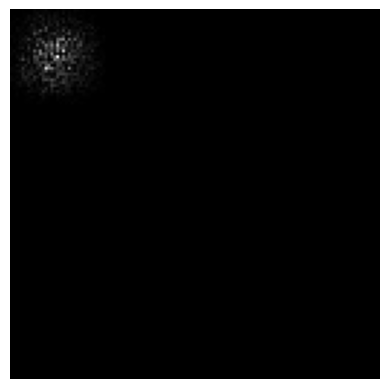

In [ ]:
from re import L
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Build a simple CNN with strided convolution layers
class define_model(nn.Module):
    def __init__(self):
        super().__init__()                                #input[1, 1, 128, 128]
        self.L1 = nn.Conv2d(1, 16, kernel_size=5, stride=1)  # [1, 16, 124, 124]
        self.L2 = nn.Conv2d(16, 16, kernel_size=5, stride=2) # [1, 16, 60, 60]
        self.L3 = nn.Conv2d(16, 16, kernel_size=3, stride=1) # [1, 16, 58, 58]
        self.L4 = nn.Conv2d(16, 16, kernel_size=3, stride=2) # [1, 16, 28, 28]
        self.L5 = nn.Conv2d(16, 16, kernel_size=3, stride=1) # [1, 16, 26, 26]
        self.L6 = nn.Conv2d(16, 16, kernel_size=3, stride=2) #[1, 16, 12, 12]

        self.activation = nn.Tanh()
        self.flatten = nn.Flatten()

        self.fc=nn.Linear(16*12*12,10)
        self.softmax=nn.Softmax(dim=1)

    def forward(self, x):
      L1=self.activation(self.L1(x))
      L2=self.activation(self.L2(L1))
      L3=self.activation(self.L3(L2))
      L4=self.activation(self.L4(L3))
      L5=self.activation(self.L5(L4))
      L6=self.activation(self.L6(L5))

      x7=self.flatten(L6)
      x8=self.fc(x7)
      x9=self.softmax(x8)

      return {
            "L1": L1,
            "L2": L2,
            "L3": L3,
            "L4": L4,
            "L5": L5,
            "L6": L6,
            "flatten": x7,
            "logits": x8,
            "output": x9,
        }

# For an output node in <model> at the intermediate layer <layer_name>
# and spatial position <x>,<y> and channel index <c>, compute the gradient of
# that output node with respect to the input <inp>
def get_gradient(model,layer_name,x,y,c,inp):

    inp = inp.clone().detach().requires_grad_(True)

    output=model(inp)
    output=output[layer_name]

    my_output = output[0,c,y,x]
    print("my_output shape:", my_output.shape)  # scalar: torch.Size([])

    model.zero_grad()
    my_output.backward()

    gradient = inp.grad
    return gradient


model = define_model()

# generate random input
inp = torch.tensor(np.random.uniform(0,1,size=(1,1,128,128)),
                                     dtype=torch.float32)

gradient = get_gradient(model,'L6',0,0,0,inp)
print("gradient shape:", gradient.shape)  # [1, 1, 128, 128]
# convert gradient to image and plot...
abs_grad = np.abs(gradient.detach().numpy()) #Convert tensor → numpy
print("absolute gradient shape:", abs_grad.shape)  # (1, 1, 128, 128)

#saliency = np.max(abs_grad, axis=1) # maximize over channels #here we have only one channel
saliency = abs_grad[0,0] # first image of batch and first channel of grad
print("saliency shape:", saliency.shape)  # (128,128)

plt.imshow(saliency, cmap="gray")  # show the first image of batch
plt.axis("off")
plt.show()



## **Task 3– Size of Receptive Fields in Convolutional Neural Networks**

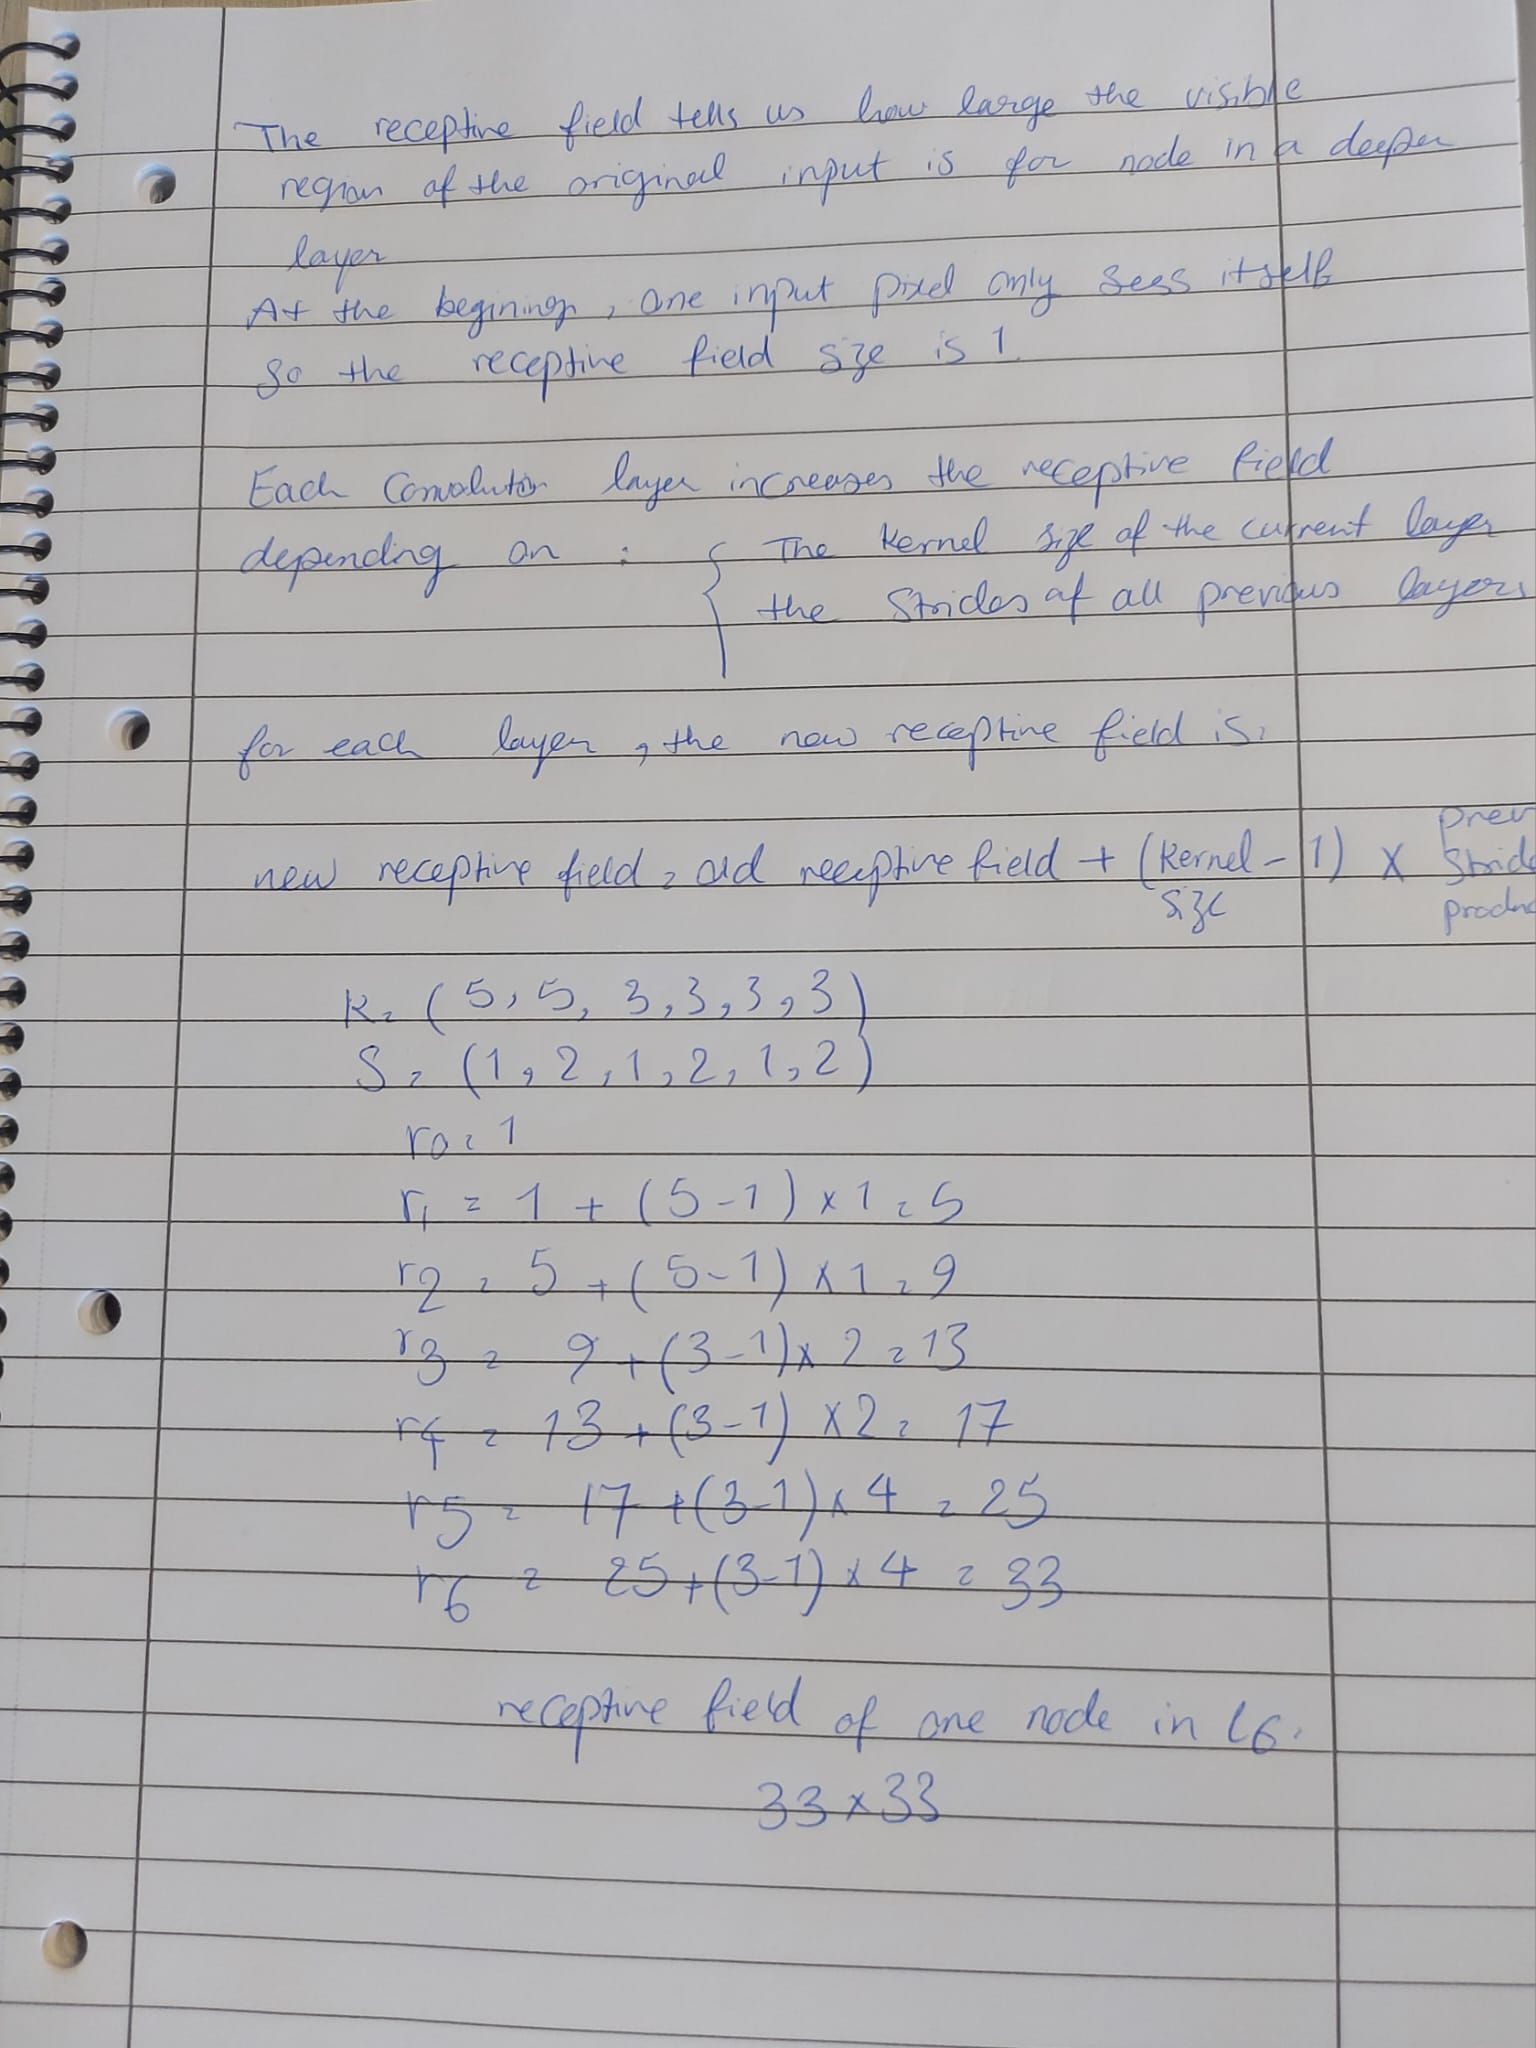

In [ ]:
#finding the receptive area
coordinate=np.argwhere(saliency) #finds all pixels where the gradient is nonzero.
y_min,x_min=coordinate.min(axis=0)

y_max,x_max=coordinate.max(axis=0)

print("y_min:",y_min)
print("x_min:",x_min)
print("y_max:",y_max)
print("x_max:",x_max)

y_min: 0
x_min: 0
y_max: 32
x_max: 32
